# Skill Pay Analysis in Germany

This notebook investigates the relationship between skill demand and salary levels for Data Engineer positions in Germany.

The analysis focuses on:

- Which skills command the highest salaries.
- Which skills are most frequently requested.
- The relationship between salary and demand.
- Practical skill-development priorities for aspiring Data Engineers.

Dataset: Data Jobs Dataset (2023)
Role: Data Engineer
Country: Germany

## Business Questions

This analysis aims to answer the following questions:

1. Which Data Engineering skills are associated with the highest salaries in Germany?
2. Which skills appear most frequently in German Data Engineer job postings?
3. Which skills provide a balance between demand and compensation?
4. What skill-development priorities emerge from the available salary data?

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

## Data Preparation

The dataset is filtered to include only Data Engineer job postings located in Germany.

Because salary analysis requires compensation information, postings without annual salary data are removed.

In [2]:
df_DE = df[
    (df["job_title_short"] == "Data Engineer")
    & (df["job_country"] == "Germany")
].copy()

total_postings = len(df_DE)

df_DE_salary = df_DE.dropna(subset=["salary_year_avg"]).copy()

salary_postings = len(df_DE_salary)
salary_coverage = round((salary_postings / total_postings) * 100, 2)

## Executive Metrics

In [3]:
metrics = pd.DataFrame({
    "Metric": [
        "Total German Data Engineer Postings",
        "Postings With Salary Data",
        "Salary Coverage (%)",
    ],
    "Value": [
        f"{total_postings:,}",
        f"{salary_postings:,}",
        f"{salary_coverage: .2f}",
    ],
})

(
    metrics.style
    .hide(axis="index")
)

Metric,Value
Total German Data Engineer Postings,"6,675"
Postings With Salary Data,39
Salary Coverage (%),0.58


## Data Quality Note

Salary information is available for only a small subset of German Data Engineer postings.

As a result, salary-related findings should be interpreted as indicative rather than representative of the entire market.

## Sample Records

In [4]:
df_DE_salary[
    [
        "job_title_short",
        "job_country",
        "salary_year_avg",
        "job_posted_date",
        "job_skills",
    ]
].sample(10, random_state=42)

,job_title_short,job_country,salary_year_avg,job_posted_date,job_skills
743909,Data Engineer,Germany,98301.5,2023-01-12 20:44:40,[azure]
768006,Data Engineer,Germany,89100.0,2023-02-22 01:34:34,"[python, sql, sql server, postgresql, azure, a..."
134666,Data Engineer,Germany,147500.0,2023-03-17 08:10:02,"[python, bigquery, tableau, looker]"
257651,Data Engineer,Germany,56700.0,2023-03-29 08:13:41,"[bash, python, azure, spark, git, bitbucket]"
692117,Data Engineer,Germany,147500.0,2023-05-01 10:14:37,"[python, java, aws, spark, pyspark, terraform]"
540098,Data Engineer,Germany,147500.0,2023-07-13 19:10:44,"[sql, aws]"
171270,Data Engineer,Germany,147500.0,2023-04-25 15:14:43,"[mongodb, mongodb, python, snowflake, kafka, a..."
547988,Data Engineer,Germany,97444.0,2023-07-07 19:13:07,"[sql, python, postgresql, aws, redshift, pyspa..."
537865,Data Engineer,Germany,147500.0,2023-03-08 19:14:34,"[sql, aws, gcp, spark, sap]"
391155,Data Engineer,Germany,56700.0,2023-01-19 19:05:29,[sql]


## Skill-Level Salary Analysis

Each job posting is expanded so that every skill can be analyzed independently.

Median salary is used instead of average salary to reduce the influence of extreme values.

In [5]:
df_DE_salary = df_DE_salary.explode("job_skills")

In [6]:
df_DE_top_pay = (
    df_DE_salary
    .groupby("job_skills")["salary_year_avg"]
    .agg(["count", "median"])
    .sort_values("median", ascending=False)
)

df_DE_top_pay = df_DE_top_pay.head(10)

(
    df_DE_top_pay
    .reset_index()
    .rename(columns={
        "job_skills": "Skill",
        "count": "Mentions",
        "median": "Median Salary (USD)"
    })
    .style
    .format({"Median Salary (USD)": lambda x: f"${int(x/1000)}K"})
    .hide(axis="index")
)

Skill,Mentions,Median Salary (USD)
github,2,$200K
matlab,1,$200K
go,1,$163K
bigquery,2,$147K
terraform,5,$147K
tableau,1,$147K
databricks,3,$147K
dynamodb,1,$147K
jira,1,$147K
looker,2,$147K


## Highest Paying Skills

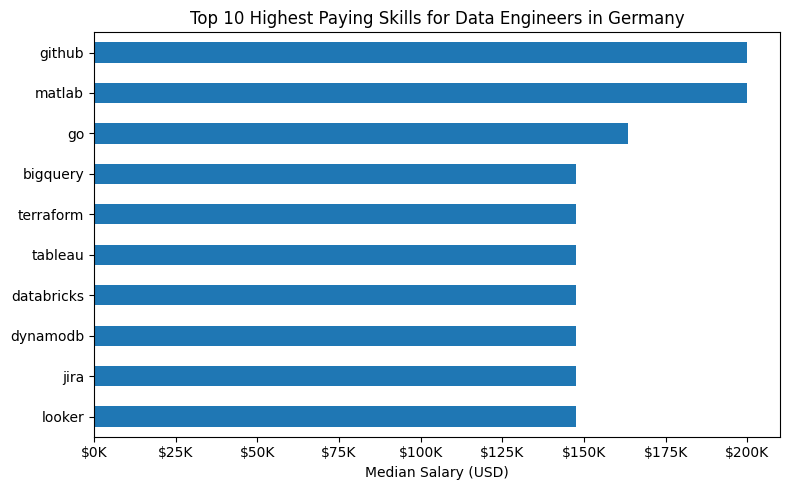

In [7]:
plt.figure(figsize=(8, 5))

df_DE_top_pay[::-1]["median"].plot(kind="barh")

plt.title("Top 10 Highest Paying Skills for Data Engineers in Germany")
plt.xlabel("Median Salary (USD)")
plt.ylabel("")

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${int(x/1000)}K")
)

plt.tight_layout()
plt.show()

## Most In-Demand Skills

In [8]:
df_DE_skills = (
    df_DE_salary
    .groupby("job_skills")["salary_year_avg"]
    .agg(["count", "median"])
    .sort_values("count", ascending=False)
)

df_DE_skills = (
    df_DE_skills
    .head(10)
    .sort_values("median", ascending=False)
)

(
    df_DE_skills
    .reset_index()
    .rename(columns={
        "job_skills": "Skill",
        "count": "Mentions",
        "median": "Median Salary (USD)"
    })
    .style
    .format({"Median Salary (USD)": lambda x: f"${int(x/1000)}K"})
    .hide(axis="index")
)

Skill,Mentions,Median Salary (USD)
spark,19,$147K
sql,19,$147K
terraform,5,$147K
aws,10,$143K
python,20,$128K
airflow,8,$122K
gcp,6,$122K
git,6,$122K
azure,8,$98K
java,6,$98K


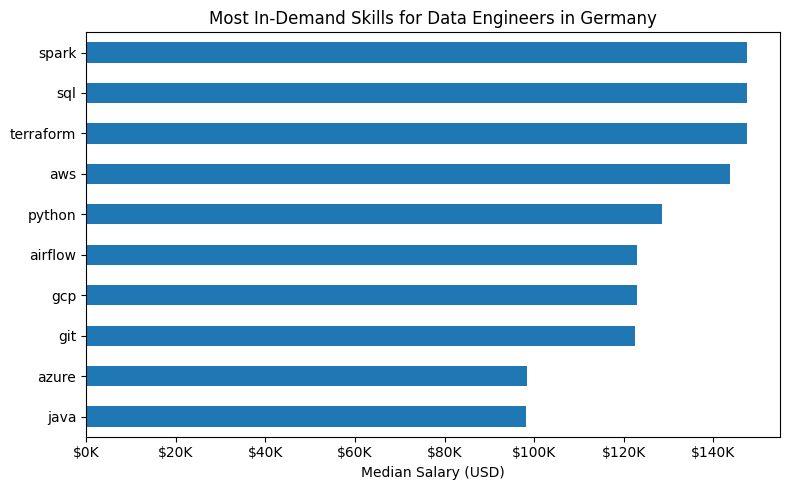

In [9]:
plt.figure(figsize=(8, 5))

df_DE_skills[::-1]["median"].plot(kind="barh")

plt.title("Most In-Demand Skills for Data Engineers in Germany")
plt.xlabel("Median Salary (USD)")
plt.ylabel("")

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${int(x/1000)}K")
)

plt.tight_layout()
plt.show()

## Salary vs Demand Comparison

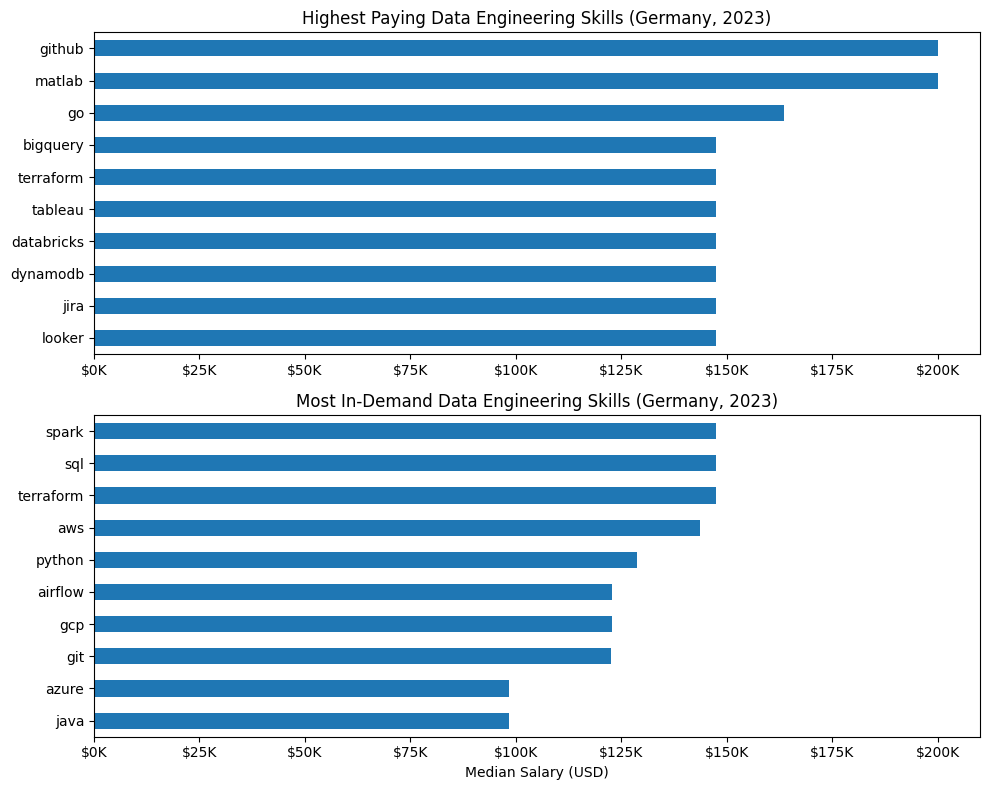

In [10]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

df_DE_top_pay[::-1].plot(
    kind="barh",
    y="median",
    ax=ax[0],
    legend=False
)

ax[0].set_title("Highest Paying Data Engineering Skills (Germany, 2023)")
ax[0].set_xlabel("")
ax[0].set_ylabel("")

ax[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${int(x/1000)}K")
)

df_DE_skills[::-1].plot(
    kind="barh",
    y="median",
    ax=ax[1],
    legend=False
)

ax[1].set_title("Most In-Demand Data Engineering Skills (Germany, 2023)")
ax[1].set_xlabel("Median Salary (USD)")
ax[1].set_ylabel("")

ax[1].set_xlim(ax[0].get_xlim())

ax[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${int(x/1000)}K")
)

plt.tight_layout()
plt.show()

## Key Findings

1. Certain specialized technologies command significantly higher salaries than the market average; however, several top-paying skills appear in only one or two salary observations.
2. Frequently requested skills are not always the highest-paying skills, highlighting a tradeoff between market demand and compensation potential.
3. Core data engineering technologies such as Python, SQL, cloud platforms, and workflow orchestration tools remain important across both salary and demand rankings.
4. Salary conclusions should be interpreted cautiously because only a small subset of German Data Engineer postings contains salary information.

## Recommendations

For aspiring Data Engineers targeting the German market:

- Build a strong foundation in Python and SQL.
- Develop cloud platform expertise.
- Learn modern data engineering tooling and workflow orchestration technologies.
- Prioritize skills that appear in both demand and salary rankings.

## Limitations

- Only 39 postings contain salary information.
- Salary results may not represent the broader German Data Engineer market.
- Compensation figures depend on employer disclosure practices.
- The dataset represents job postings rather than actual accepted salaries.

## Conclusion

This analysis explored the relationship between skills, salary, and demand within German Data Engineer job postings.

While salary coverage is limited, the results provide useful insight into which technologies appear to command premium compensation and which skills remain consistently valuable in the market.

Together with the job demand and skill trend analyses, this notebook completes a broader view of the German Data Engineering job market.